In [1]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd, seaborn as sns, scipy.stats as stats
import os, glob

from data.movie import Frames, Audio, People # Measures
from data.spikes import Rates # LFP, BOLD
from data.behavior import Gaze, Suspense # Suspense, Valence, Arousal

from tqdm import tqdm

### helpers

In [2]:
rescale_t = 1

# def min_max(x, y=None):
#     """    Rescale x to [0, 1] using min and max of y if provided,
#     otherwise use min and max of x.
#     """
#     ref = x if y is None else y
#     min_val = ref.min()
#     max_val = ref.max()
#     return (x - min_val) / (max_val - min_val + 1e-8)

min_max = lambda x: (x - x.min()) / (x.max() - x.min())

def get_clean_df(df):

    clean_df = df.copy()
    
    clean_df = clean_df.iloc[:, np.isfinite(clean_df.values).all(axis=0)] # remove nan/inf cols
    clean_df = clean_df.iloc[:, (clean_df.mean(axis=0) > 0).values] # remove low-FR cols
    
    print(f'dropping {df.shape[1] - clean_df.shape[1]} neurs.\nRetaining {clean_df.shape[1]} neurs.')
    return clean_df


# loading/formatting data

### 1. X: neur_N_by_T

/home/nuttidalab/Documents/rudra/movie_analysis/data/spikes/rate.py:51: RuntimeWarning: divide by zero encountered in divide
  enc_rate_normed = (enc_rates - base_mean) / base_sd
/home/nuttidalab/Documents/rudra/movie_analysis/data/spikes/rate.py:51: RuntimeWarning: invalid value encountered in divide
  enc_rate_normed = (enc_rates - base_mean) / base_sd


dropping 491 neurs.
Retaining 966 neurs.
(966, 479)


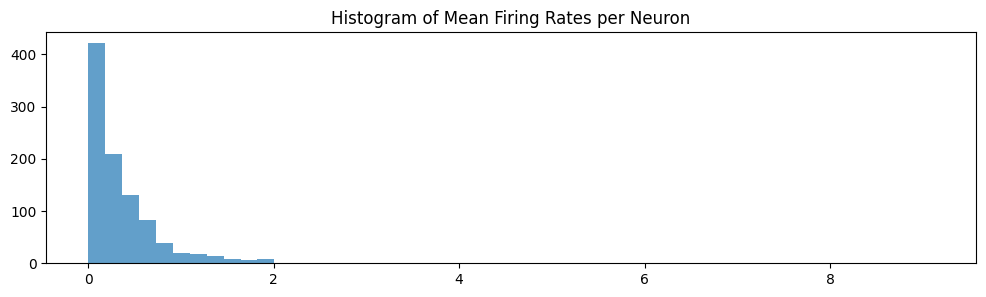

,Right_ACC_P58CS_R1_35_1_2195_5,Right_ACC_P58CS_R1_34_4_3301_5,Right_ACC_P58CS_R1_34_2_3239_5,Right_ACC_P58CS_R1_34_1_3232_5,Right_ACC_P58CS_R1_36_1_712_5,Right_ACC_P58CS_R1_36_2_962_5,Right_ACC_P58CS_R1_38_1_1473_5,Right_ACC_P58CS_R1_39_1_1433_5,Right_ACC_P58CS_R1_40_1_1392_5,Right_ACC_P58CS_R1_40_2_1469_5,...,Right_amygdala_P62CS_R1_31_1_2053_3,Right_amygdala_P62CS_R1_31_2_2063_3,Right_amygdala_P62CS_R1_32_5_6098_3,Right_amygdala_P62CS_R1_28_4_6400_3,Right_amygdala_P62CS_R1_32_7_6127_3,Right_amygdala_P62CS_R1_25_3_3529_3,Right_amygdala_P62CS_R1_27_7_8732_3,Right_preSMA_P62CS_R1_18_2_3846_7,Right_vmPFC_P62CS_R1_7_1_791_9,Right_vmPFC_P62CS_R1_5_1_1374_9
0.0,-0.107521,-0.923221,-0.088289,-0.390434,2.244494,0.302122,0.393852,0.739063,2.372100,0.214906,...,-0.266889,0.461183,0.479499,1.142623,0.892620,0.801637,1.105981,1.280264,-0.457766,-0.062201
1.0,-0.107521,-1.000089,0.340222,-0.390434,2.887818,1.296439,1.549817,0.369196,1.039705,-0.420460,...,-0.266889,0.181959,1.085665,0.232678,1.706616,-0.198789,1.131763,0.209403,-0.005204,-0.294342
2.0,-0.107521,-0.134325,0.593294,-0.390312,6.613831,1.113987,0.294318,1.026067,1.219149,0.170388,...,-0.209911,-0.191976,0.913765,0.906874,0.839210,0.011677,0.601093,0.858131,-0.225080,-0.296496
3.0,-0.107521,2.040038,0.389511,0.292734,2.013020,1.050507,1.038302,0.235216,-0.164647,-0.234131,...,0.416918,-0.192143,0.778260,1.096310,1.195550,0.596177,0.679405,0.476378,0.028679,-0.220789
4.0,-0.107521,0.512235,-0.457154,0.516420,0.090433,0.260862,0.102534,-0.144338,-0.171231,-0.428097,...,0.029847,-0.192143,0.659739,0.875926,0.908040,-0.058588,0.833012,0.302962,0.120814,0.327731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474.0,-0.107521,0.031678,0.119806,0.087395,-0.107521,-0.257123,-0.462101,-0.144338,-0.171298,-0.390489,...,0.753927,-0.192143,0.339228,-0.000781,0.546652,-0.285890,-0.065369,0.812446,0.228790,0.044538
475.0,0.076115,-0.292360,0.286691,-0.116771,-0.107521,0.219609,0.014690,-0.144338,-0.171499,0.332348,...,-0.266629,-0.192143,0.537460,-0.593355,0.633420,0.748504,0.020661,-0.409717,0.229811,0.703491
476.0,2.844863,-0.093900,0.245846,-0.386153,-0.107521,0.709171,-0.455701,-0.144338,-0.171499,-0.377876,...,-0.266889,-0.192143,0.597261,-0.227525,0.596048,0.498692,1.324447,-0.000177,0.352840,0.230458
477.0,2.233755,0.705968,0.836228,0.455036,0.030206,0.268840,-0.489116,-0.144338,-0.083627,-0.039935,...,-0.266889,-0.192143,-0.064541,0.224102,0.505282,-0.121619,1.596634,-0.224824,0.028679,0.538756


In [3]:
df_FRs = Rates().rescale(rescale_t)
clean_df_FRs = get_clean_df(df_FRs)

neur_T_by_N, neur_N_by_T = clean_df_FRs.values, clean_df_FRs.values.T
print(neur_N_by_T.shape)

plt.figure(figsize=(12, 3))
plt.hist(neur_T_by_N.mean(axis=0), bins=50, alpha=0.7)
plt.title('Histogram of Mean Firing Rates per Neuron')
plt.show()

clean_df_FRs


In [4]:
regions = ['ACC', 'amygdala', 'hippocampus', 'vmPFC', 'preSMA']

amyg_df = clean_df_FRs[[col for col in clean_df_FRs.columns if 'amyg' in col]]
amyg_T_by_N, amyg_N_by_T = amyg_df.values, amyg_df.values.T
ACC_df = clean_df_FRs[[col for col in clean_df_FRs.columns if 'ACC' in col]]
ACC_T_by_N, ACC_N_by_T = ACC_df.values, ACC_df.values.T
hippo_df = clean_df_FRs[[col for col in clean_df_FRs.columns if 'hippo' in col]]
hippo_T_by_N, hippo_N_by_T = hippo_df.values, hippo_df.values.T
vmPFC_df = clean_df_FRs[[col for col in clean_df_FRs.columns if 'vmPFC' in col]]
vmPFC_T_by_N, vmPFC_N_by_T = vmPFC_df.values, vmPFC_df.values.T
preSMA_df = clean_df_FRs[[col for col in clean_df_FRs.columns if 'preSMA' in col]]
preSMA_T_by_N, preSMA_N_by_T = preSMA_df.values, preSMA_df.values.T

### 2. Y1: sens_N_by_T and sens_N_by_T

visual

In [5]:
visual = Frames()
visual_metrics = [
    visual.objects.people_count,
    visual.cuts.scene,
    visual.cuts.camera,
    visual.measures.l1,
    visual.measures.l2,
    # visual.measures.cosine,
    # visual.measures.ssim,
    visual.measures.wasserstein,
    # visual.measures.correlation
]

100%|██████████| 144/144 [00:00<00:00, 241.81it/s]


(6, 479)


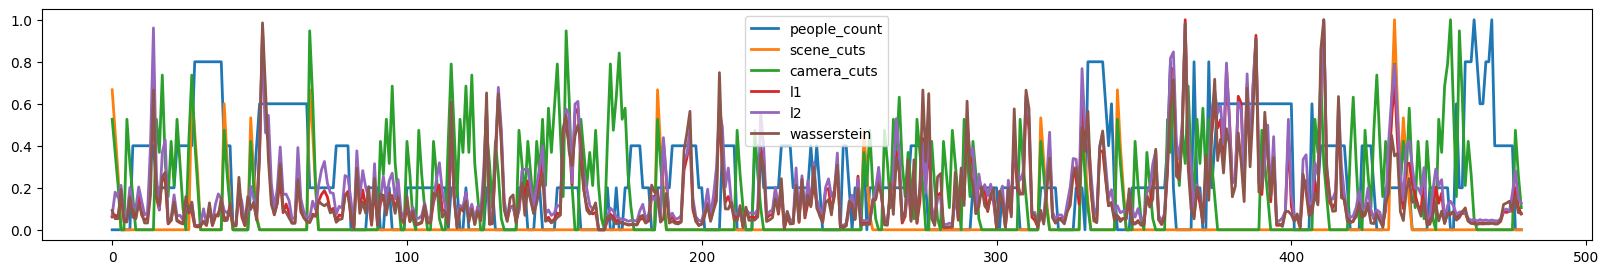

In [6]:
# apply rescaling and stack into a matrix
rescaled_metrics = [data.rescale(1) for data in visual_metrics]
vis_T_by_N = np.stack(rescaled_metrics, axis=1)
vis_N_by_T = vis_T_by_N.T
print(vis_N_by_T.shape)

# plot
visual_df = pd.DataFrame(vis_T_by_N, columns=[
    'people_count', 'scene_cuts', 'camera_cuts',
    'l1', 'l2', 'wasserstein'
])
plt.figure(figsize=(20, 3))
for col in visual_df.columns:
    # if not col == 'wasserstein': continue
    plt.plot(min_max(visual_df[col]), label=col, linewidth=2)
plt.legend()
plt.show()

audio

In [7]:
audio = Audio()
audio_metrics = [
    audio.vocals.arousal,
    audio.vocals.dominance,
    audio.vocals.valence,
    # audio.vocals.angry,
    audio.vocals.sad,
    audio.vocals.happy,
    # audio.vocals.surprise,
    audio.vocals.neutral,
]

(6, 479)


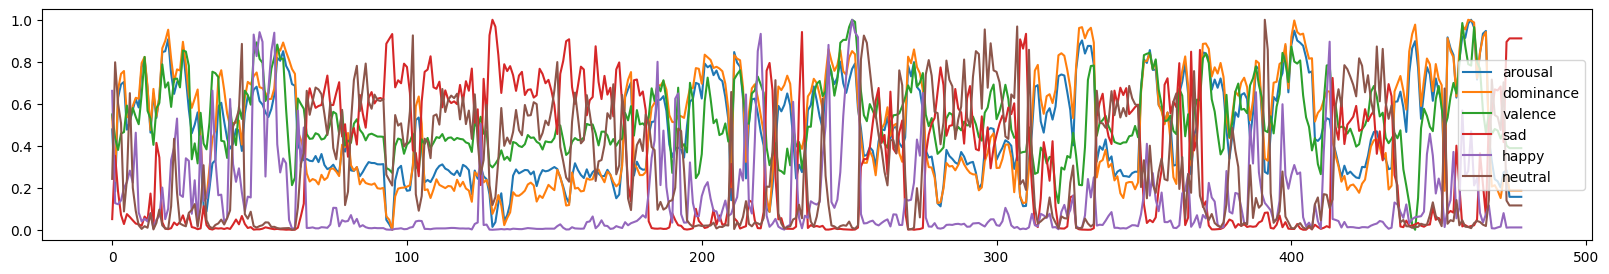

In [8]:
# apply rescaling and stack into a matrix
rescaled_metrics = [data.rescale(1) for data in audio_metrics]
aud_T_by_N = np.stack(rescaled_metrics, axis=1)
aud_N_by_T = aud_T_by_N.T
print(aud_N_by_T.shape)

# plot
audio_df = pd.DataFrame(aud_T_by_N, columns=['arousal', 'dominance', 'valence','sad', 'happy','neutral'])
plt.figure(figsize=(20, 3))
for col in audio_df.columns:
    plt.plot(min_max(audio_df[col]), label=col)
plt.legend()
plt.show()

combine

(1, 479)


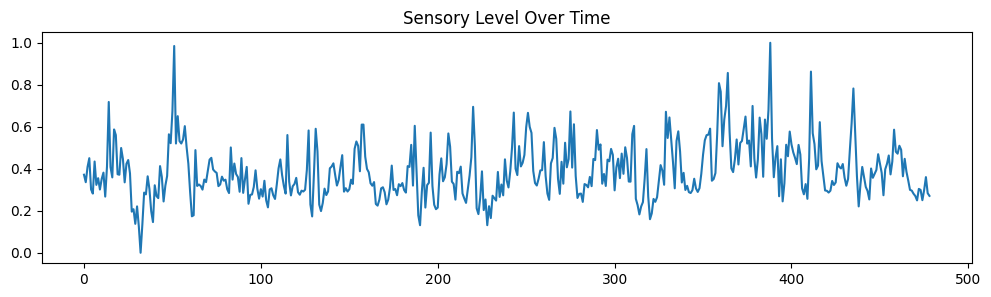

In [9]:
aud_level = min_max(aud_T_by_N.mean(axis=1))
vis_level = min_max(vis_T_by_N.mean(axis=1))
sens_N_by_T = ((aud_level + vis_level) / 2).reshape(1, -1)
# sens_N_by_T = np.concatenate([aud_T_by_N, vis_T_by_N], axis=1).T
sens_T_by_N = sens_N_by_T.T
print(sens_N_by_T.shape)
sens_df = pd.DataFrame(sens_T_by_N, columns=['sensory_level'])

plt.figure(figsize=(12, 3))
plt.plot(min_max(sens_T_by_N.mean(axis=1)))
plt.title('Sensory Level Over Time')
plt.show()  

### 3. Y2: susp_N_T

(1, 479)


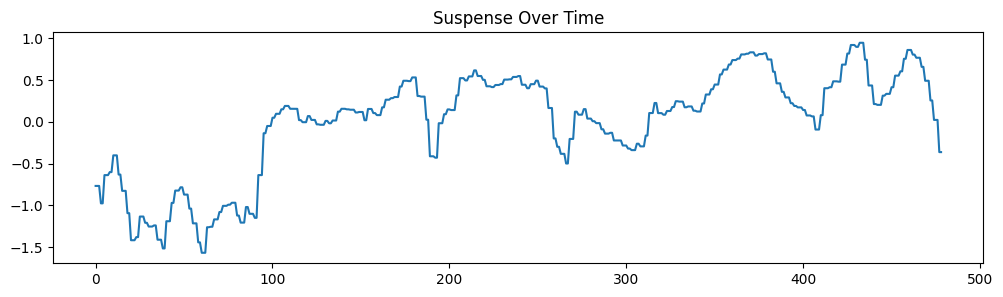

In [10]:
suspense = Suspense().rescale(rescale_t)
avg_suspense = suspense.mean(axis=1)
df_susp = pd.DataFrame(avg_suspense, columns=['suspense'])
susp_N_by_T = avg_suspense[np.newaxis, :]
print(susp_N_by_T.shape)

plt.figure(figsize=(12, 3))
plt.title('Suspense Over Time')
plt.plot(avg_suspense)
plt.show()

## get correlated neurons

In [11]:
def get_corr_neurs(neur_df, visual_df, audio_df, susp_df):
    """
    Get corr_df and pval_df of each neur col with each col of visual, audio, and suspense dataframes.
    """
    corr_df = pd.DataFrame(index=neur_df.columns, columns=visual_df.columns.tolist() + audio_df.columns.tolist() + susp_df.columns.tolist())
    pval_df = pd.DataFrame(index=neur_df.columns, columns=visual_df.columns.tolist() + audio_df.columns.tolist() + susp_df.columns.tolist())

    for neur_col in tqdm(neur_df.columns):
        
        for vis_col in visual_df.columns:
            corr, pval = stats.pearsonr(neur_df[neur_col], visual_df[vis_col])
            corr_df.loc[neur_col, vis_col] = corr
            pval_df.loc[neur_col, vis_col] = pval

        for aud_col in audio_df.columns:
            corr, pval = stats.pearsonr(neur_df[neur_col], audio_df[aud_col])
            corr_df.loc[neur_col, aud_col] = corr
            pval_df.loc[neur_col, aud_col] = pval
        
        for susp_col in susp_df.columns:
            corr, pval = stats.pearsonr(neur_df[neur_col], susp_df[susp_col])
            corr_df.loc[neur_col, susp_col] = corr
            pval_df.loc[neur_col, susp_col] = pval

    return corr_df.astype(float), pval_df.astype(float)
    
# Get correlation dataframes
neur_corrs, neur_pvals = get_corr_neurs(clean_df_FRs, visual_df, audio_df, df_susp)
neur_corrs = neur_corrs.reset_index().rename(columns={'index': 'neuron'})
neur_pvals = neur_pvals.reset_index().rename(columns={'index': 'neuron'})
neur_corrs

100%|██████████| 966/966 [00:01<00:00, 553.95it/s]


,neuron,people_count,scene_cuts,camera_cuts,l1,l2,wasserstein,arousal,dominance,valence,sad,happy,neutral,suspense
0,Right_ACC_P58CS_R1_35_1_2195_5,0.035208,-0.001736,-0.031279,-0.039420,-0.037155,-0.029795,-0.043730,-0.052286,0.014711,-0.001085,-0.004042,0.039103,-0.177434
1,Right_ACC_P58CS_R1_34_4_3301_5,-0.065109,0.068741,0.075554,-0.043613,-0.060825,-0.018030,-0.016013,0.015817,-0.028941,-0.026223,0.069263,-0.062181,-0.045350
2,Right_ACC_P58CS_R1_34_2_3239_5,0.067705,0.036262,-0.038847,-0.036236,-0.030333,-0.027356,0.016357,0.043810,-0.133713,-0.074310,-0.028620,-0.057001,-0.100961
3,Right_ACC_P58CS_R1_34_1_3232_5,0.008050,-0.113097,-0.042631,0.031158,0.032213,0.039823,-0.027019,-0.029904,0.040867,0.001613,0.010558,0.032799,-0.053814
4,Right_ACC_P58CS_R1_36_1_712_5,0.128921,-0.004331,0.072624,0.096781,0.104373,0.077217,0.050261,0.067986,0.079819,-0.059906,0.064455,-0.041895,-0.053208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
961,Right_amygdala_P62CS_R1_25_3_3529_3,-0.013609,-0.072619,-0.011347,-0.003235,0.000796,-0.003620,-0.045645,-0.055920,-0.100527,0.050500,-0.094609,-0.009815,0.031335
962,Right_amygdala_P62CS_R1_27_7_8732_3,0.002827,-0.025852,0.039302,-0.034600,-0.036058,-0.017568,-0.105691,-0.093694,-0.002801,0.045407,0.063392,-0.003147,-0.258271
963,Right_preSMA_P62CS_R1_18_2_3846_7,0.057583,-0.004486,-0.112902,0.053516,0.071725,0.056519,0.032613,0.033739,0.033818,-0.083869,0.072039,-0.014660,-0.161059
964,Right_vmPFC_P62CS_R1_7_1_791_9,0.087543,0.049468,-0.071661,0.012159,0.014729,-0.008527,-0.033014,-0.010338,-0.035429,-0.037047,0.010828,-0.018359,-0.068595


In [12]:
for metric in neur_corrs.columns:

    if metric == 'neuron': continue
    tuned_neurs = neur_corrs.index[(neur_corrs[metric] > 0.2) & (neur_pvals[metric] < 0.05)]
    print(f'Found {len(tuned_neurs)} neurons with significant correlation to {metric}.')

Found 14 neurons with significant correlation to people_count.
Found 4 neurons with significant correlation to scene_cuts.
Found 2 neurons with significant correlation to camera_cuts.
Found 3 neurons with significant correlation to l1.
Found 2 neurons with significant correlation to l2.
Found 1 neurons with significant correlation to wasserstein.
Found 11 neurons with significant correlation to arousal.
Found 13 neurons with significant correlation to dominance.
Found 1 neurons with significant correlation to valence.
Found 19 neurons with significant correlation to sad.
Found 7 neurons with significant correlation to happy.
Found 12 neurons with significant correlation to neutral.
Found 38 neurons with significant correlation to suspense.


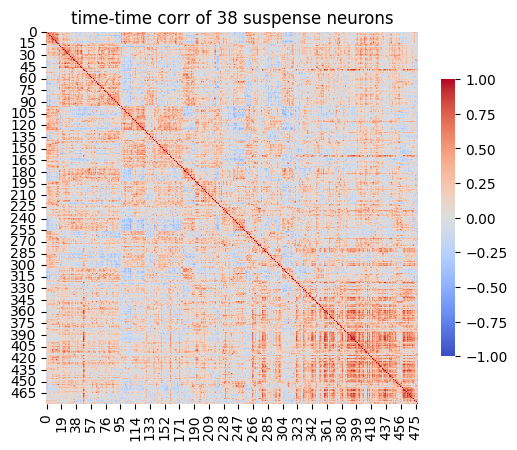

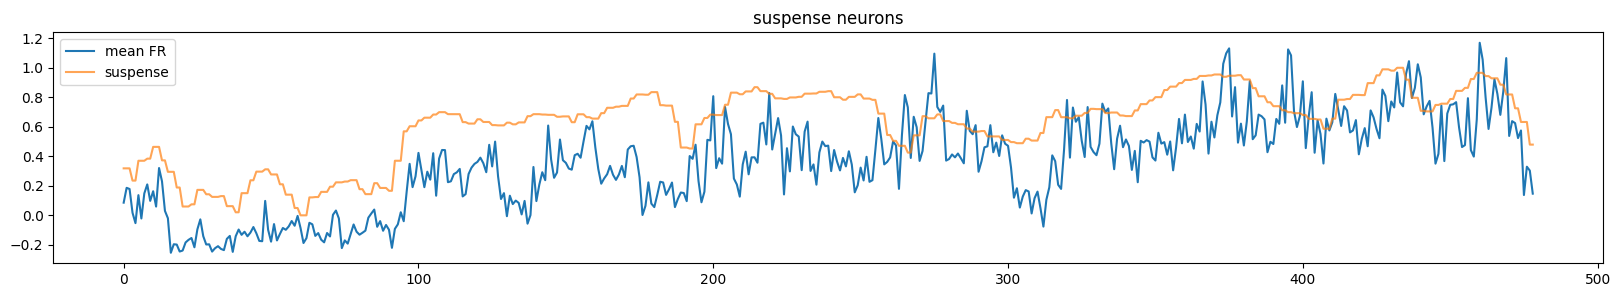

In [13]:
# plot time by time corr of susp_neurs
susp_neurs = neur_corrs[
    (neur_corrs['suspense'] > .2) & 
    (neur_pvals['suspense'] < .05)
]['neuron'].tolist()
susp_neur_df = clean_df_FRs[susp_neurs]
susp_neur_N_by_T, susp_neur_T_by_N = susp_neur_df.values.T, susp_neur_df.values

plt.figure(figsize=(6,6))
sns.heatmap(np.corrcoef(susp_neur_df), square=True, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={'shrink': .6})
plt.title(f'time-time corr of {len(susp_neurs)} suspense neurons')
plt.show()

# also plot
plt.figure(figsize=(20, 3))
plt.plot(susp_neur_df.mean(axis=1), label='mean FR')
plt.plot(min_max(avg_suspense), label='suspense', alpha=0.7)
# plt.plot(gaze_objs['gun_with_protagonist'], label='gaze gun with protagonist', alpha=0.7)
# plt.plot(np.diag(np.corrcoef(susp_neur_df), 15), label='lagged autocorr')
plt.legend()
plt.title('suspense neurons')
plt.show()


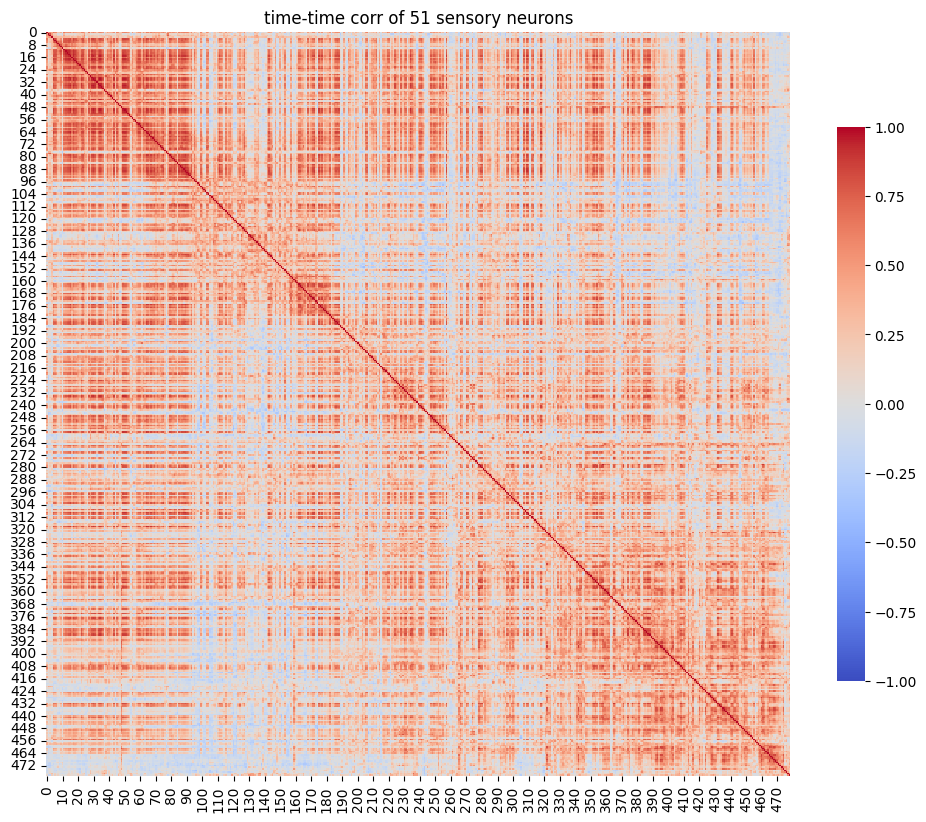

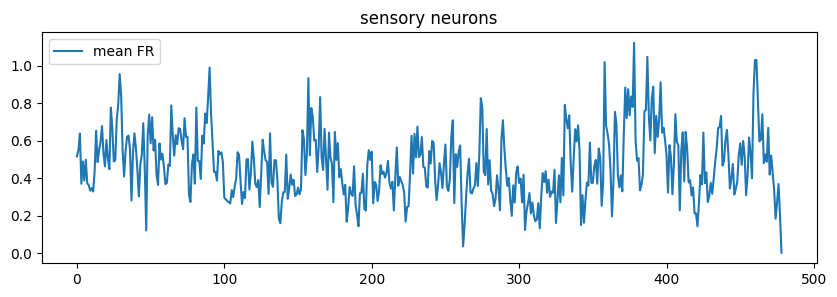

In [14]:
sens_neurs = neur_corrs[
    (neur_corrs.drop(columns=['neuron', 'suspense', 'happy', 'neutral']) > 0.2).any(axis=1) &
    (neur_pvals.drop(columns=['neuron', 'suspense', 'happy', 'neutral']) < 0.05).any(axis=1)
]['neuron'].tolist()
sens_neur_df = clean_df_FRs[sens_neurs]

plt.figure(figsize=(12,12))
sns.heatmap(np.corrcoef(sens_neur_df), square=True, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={'shrink': .6})
plt.title(f'time-time corr of {len(sens_neurs)} sensory neurons')
plt.show()

# also plot
plt.figure(figsize=(10, 3))
plt.plot(sens_neur_df.mean(axis=1), label='mean FR')
# plt.plot(np.diag(np.corrcoef(sens_neur_df), 15), label='autocorr')
plt.legend()
plt.title('sensory neurons')
plt.show()


## 4. gaze objects

475


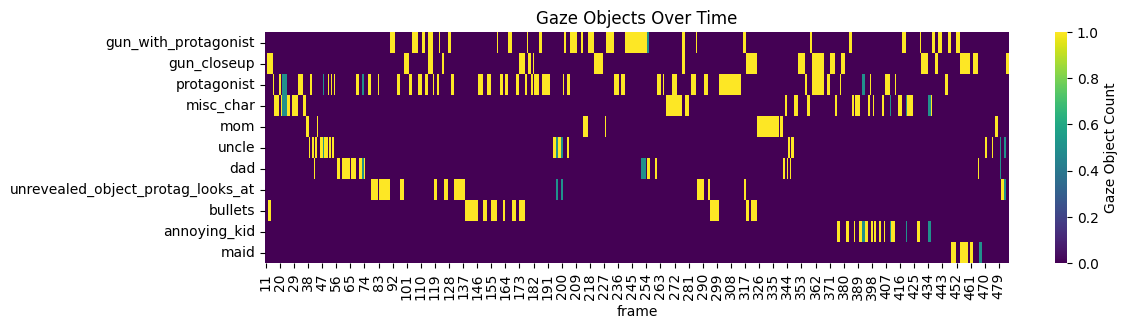

In [15]:
gaze_objs_df = pd.read_csv('../data/bin/P54CS_R1_gaze.csv', index_col=0)
gaze_objs_T_by_N = gaze_objs_df.values
gaze_objs_N_by_T = gaze_objs_T_by_N.T
print(len(gaze_objs_df))

plt.figure(figsize=(12, 3))
plt.title('Gaze Objects Over Time')
sns.heatmap(gaze_objs_df.T, cmap='viridis', cbar_kws={'label': 'Gaze Object Count'})
plt.show()

In [16]:
# plt.figure(figsize=(20, 3))
# plt.plot(gaze_objs_df['gun_with_protagonist'], label='gaze gun with protagonist', alpha=0.7)
# plt.plot(min_max(avg_suspense), label='suspense', alpha=0.7)
# plt.plot(susp_N_by_T.mean(axis=0), label='suspense mean FR', alpha=0.7)
# plt.title('Gaze at Gun with Protagonist Over Time')
# plt.legend()
# plt.show()

# template matching

In [17]:
susp_amyg_df = susp_neur_df[[col for col in susp_neur_df.columns if 'amyg' in col]]
susp_amyg_N_by_T, susp_amyg_T_by_N = susp_amyg_df.values.T, susp_amyg_df.values
susp_amyg_df

,Left_amygdala_P58CS_R1_23_3_3484_4,Right_amygdala_P55CS_R1_53_3_6124_3,Right_amygdala_P55CS_R1_49_4_5577_3,Left_amygdala_P48CS_R1_24_2_2768_4,Left_amygdala_P47CS_R2_21_2_2725_4,Right_amygdala_P47CS_R1_53_1_507_3,Left_amygdala_P54CS_R1_21_3_5519_4,Right_amygdala_P54CS_R1_50_2_5595_3,Right_amygdala_P62CS_R2_29_3_8468_3,Right_amygdala_P62CS_R2_30_4_6292_3,Right_amygdala_P62CS_R2_32_6_6115_3
0.0,0.013477,-0.287615,-0.557604,-0.223607,0.359951,-0.152944,0.316559,0.013315,-0.152944,-0.107521,1.328913
1.0,-0.008522,-0.287615,-0.557604,-0.223607,0.785416,-0.152944,0.167685,0.287897,-0.152944,-0.107521,-0.171231
2.0,1.471947,-0.287615,-0.557604,-0.223607,0.708498,-0.152944,1.037792,-0.037567,-0.152944,-0.107521,-0.171499
3.0,0.090558,-0.287615,-0.557604,-0.223476,-0.603866,-0.152944,0.927541,0.550949,-0.152944,-0.107521,-0.171499
4.0,-0.125545,-0.287615,-0.557604,0.168220,-0.003333,-0.152944,-0.383651,-0.174318,-0.152944,-0.107521,-0.171499
...,...,...,...,...,...,...,...,...,...,...,...
474.0,-0.697246,-0.287526,-0.538705,-0.223607,0.618473,1.123189,0.891349,-0.212444,-0.152944,0.030206,1.322464
475.0,-0.427366,-0.287615,-0.557604,-0.211696,0.124305,2.527092,0.096272,-0.288447,-0.152944,-0.107101,1.604130
476.0,-0.672145,-0.287615,-0.557604,1.589227,0.664685,4.497174,0.370756,-0.685044,-0.142760,0.834522,-0.054069
477.0,0.181162,-0.287615,-0.557604,0.364395,0.591970,-0.130031,0.811481,-0.266744,1.917017,1.537332,1.328913


In [18]:
def get_neur_template(susp_neur_df, gaze_obj_df):
    """
    get an avg neural template within a window around gaze events
    """

    assert susp_neur_df.shape[0] == gaze_obj_df.shape[0], f'{susp_neur_df.shape[0]} != {gaze_obj_df.shape[0]}'

    # time window to get event template
    bin_start, bin_stop = 1, 2
    susp_neur_N_by_T = susp_neur_df.values.T
    gaze_obj_by_T = gaze_obj_df.values.T
    N = susp_neur_N_by_T.shape[0]

    # time indices of events
    event_ids = np.where(gaze_obj_by_T > 0)[0]
    print(f'{len(event_ids)} events')
    neur_templates = []
    
    for event_idx in event_ids:

        if (event_idx - bin_start < 0) or (event_idx + bin_stop >= gaze_obj_by_T.shape[0]): continue

        neur_template = susp_neur_N_by_T[:, event_idx - bin_start : event_idx + bin_stop]
        neur_templates.append(neur_template)

    print(f'{len(neur_templates)} templates')
    
    mean_neur_template = np.mean(neur_templates, axis=0)
    assert mean_neur_template.shape[0] == N, f'{mean_neur_template.shape[0]} != {N}'

    return mean_neur_template

In [19]:
# if either gun col>0, gaze_objs_df['gun'] = 1
gaze_objs_df['gun'] = (gaze_objs_df['gun_with_protagonist'] > 0) | (gaze_objs_df['gun_closeup'] > 0)
gaze_obj = 'gun'
neur_template = get_neur_template(susp_neur_df.iloc[:-4], gaze_objs_df[gaze_obj])

135 events
133 templates


3 38 479


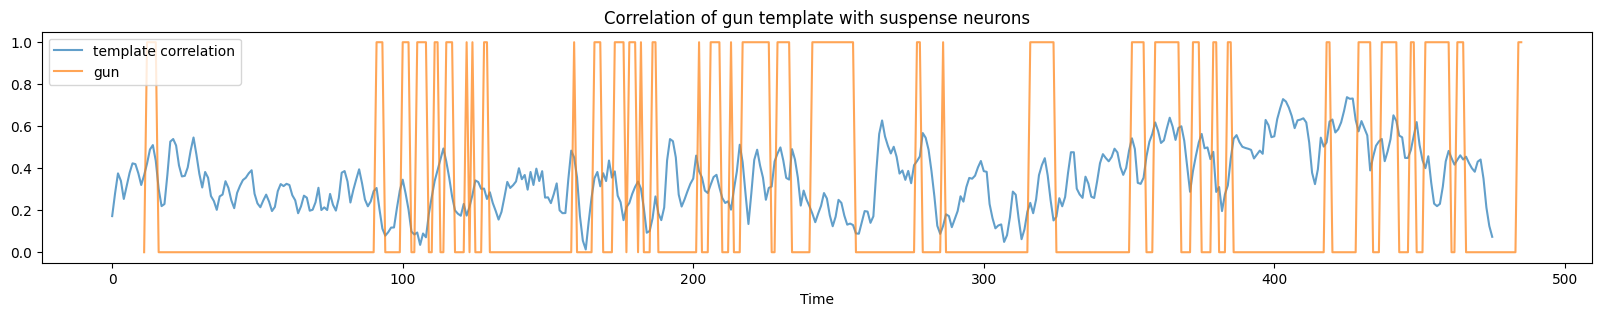

In [20]:
template_corrs = []
template_window = neur_template.shape[1]
N, T = susp_neur_N_by_T.shape
print(template_window, N, T)

for t in range(T - template_window):

    neur_activity = susp_neur_N_by_T[:, t:t+template_window]
    template_corrs.append(
        np.corrcoef(neur_template.flatten(), neur_activity.flatten())[0, 1]
    )

plt.figure(figsize=(20, 3))
plt.title('Correlation of gun template with suspense neurons')

plt.plot(template_corrs, label='template correlation', alpha=0.7)
plt.plot(gaze_objs_df[gaze_obj], label=gaze_obj, alpha=0.7)

plt.xlabel('Time')
# plt.ylabel('Correlation Coefficient')
plt.legend()
plt.show()

## Decoding

In [21]:
# 29 sessions=trials=samples, 479 timepoints (479 x 29 x PC(N))
# we want cross-temporal decoding; itll be 479*479 mtx
# decodiong median split of arousal

In [83]:
def get_values_from_cols(cols):
    subject_vals = []
    for s_name in cols:
        subjects_columns = []
        for col in clean_df_FRs.columns:
            if s_name in col:
                subjects_columns.append(col)

        # print(subjects_columns)
        subject_vals.append(clean_df_FRs[subjects_columns].values)
        # break
    return subject_vals

In [84]:
subject_names = np.unique([ col.split("_")[2] + "_" + col.split("_")[3] for col in clean_df_FRs.columns])
subject_vals = get_values_from_cols(subject_names)

In [91]:
good_subjects = []
for i, subject_val in enumerate(subject_vals):
    if len(subject_val[0]) > 3:
        good_subjects.append(subject_names[i])
good_vals = get_values_from_cols(good_subjects)

In [94]:
# import pca
from sklearn.decomposition import PCA
pca = PCA(n_components=6)  # Adjust n_components as needed

In [100]:
spc = []
cum_vars = []

for subject_val in tqdm(good_vals):
    
    # print(subject_val.shape)
    pc_val = pca.fit_transform(subject_val)
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    # cum_var = pca.explained_variance_ratio_
    
    # print(pc_val.shape)
    spc.append(pc_val)
    cum_vars.append(cum_var)
    
spc = np.array(spc)
cum_vars = np.array(cum_vars)

100%|██████████| 28/28 [00:00<00:00, 795.09it/s]


In [96]:
spc.shape, cum_vars.shape

((28, 479, 6), (28, 6))

In [137]:
x = spc.transpose(1,0,2)
# y = np.repeat((avg_suspense > np.median(avg_suspense)).reshape(-1, 1), 28, axis=1)
y = np.repeat(min_max(avg_suspense).reshape(-1, 1), len(good_subjects), axis=1)

In [138]:
x.shape, y.shape

((479, 28, 6), (479, 28))

In [139]:
# import binary classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# linear regression instead
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [126]:
x_ = []
y_ = []

x_cv = []
y_cv = []
for i in range(x.shape[0]):
    t_x = x[i]
    t_y = y[i]
    x_train, x_test, y_train, y_test = train_test_split(t_x, t_y, test_size=0.2, random_state=42)
    
    x_.append(x_train)
    y_.append(y_train)
    x_cv.append(x_test)
    y_cv.append(y_test)
    
x_ = np.array(x_)
y_ = np.array(y_)
x_cv = np.array(x_cv)
y_cv = np.array(y_cv)

In [127]:
x_.shape, y_.shape, x_cv.shape, y_cv.shape

((479, 22, 6), (479, 22), (479, 6, 6), (479, 6))

In [ ]:
from joblib import Parallel, delayed

In [145]:
metric = []
mes = []
for j in tqdm(range(479)):

    v_x_cv = x_cv[j]
    v_y_cv = y_cv[j]
    
    r_metric = []
    r_mse = []

    for i in range(479):
        
        # model = LogisticRegression(max_iter=1000)
        model = LinearRegression()
        model.fit(x_[i], y_[i])
        
        y_pred = model.predict(v_x_cv)

        # score = accuracy_score(v_y_cv, y_pred)
        score = r2_score(v_y_cv, y_pred)
        mse = mean_squared_error(v_y_cv, y_pred)
        
        r_metric.append(score)
        r_mse.append(mse)
    
    metric.append(r_metric)
    mes.append(r_mse)

    

100%|██████████| 479/479 [01:41<00:00,  4.70it/s]


In [147]:
metric = np.array(metric)
mse = np.array(mes)
metric.shape, mse.shape

((479, 479), (479, 479))

<Axes: >

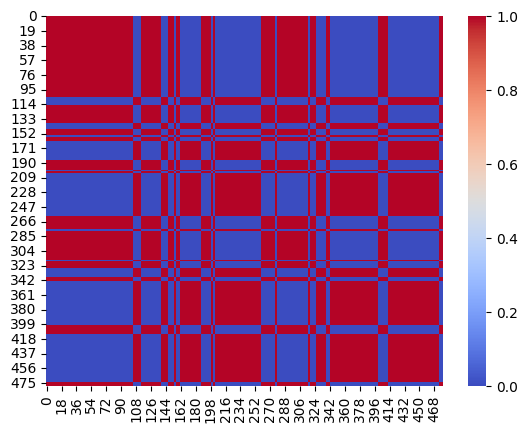

In [148]:
sns.heatmap(metric, cmap='coolwarm', vmin=0, vmax=1)

<Axes: >

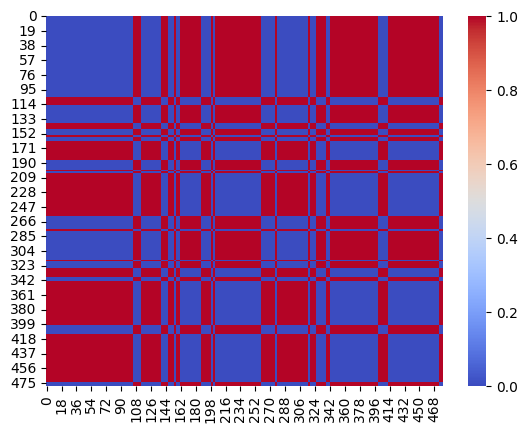

In [149]:
sns.heatmap(mse, cmap='coolwarm', vmin=0, vmax=1)